# Forest plots

A **forest plot** is a graphical summary commonly used in medical research, particularly in meta-analyses and clinical trials, to display estimates from multiple studies or subgroups. It provides a compact visualisation of the point estimates (e.g. risk ratios, odds ratios, mean differences) and their associated confidence intervals, often aligned along a shared axis to facilitate comparison.

Each row in a forest plot typically represents a study or the result of a single analysis. A central marker (such as a dot or square) indicates the effect estimate, while a horizontal line represents its confidence interval, usually at the 95% level. A vertical reference line — often placed at 1 for ratio measures or 0 for absolute differences — indicates the null effect. Estimates crossing this line suggest statistical non-significance.

In this notebook, we explore the construction of forest plots from tabular data, and demonstrate how to customise aesthetics, include group labels, and add annotation panels or supplementary tables.


In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plot_misc.forest as forest
import plot_misc.example_data.examples as examples
from scipy.stats import norm
from matplotlib.lines import Line2D
from plot_misc import utils as plm_utils

In [2]:
# import example data
combined = examples.load_forest_data()
combined.reset_index(drop=True, inplace=True)

# constants
CMTOINCH = 1/2.54
SHAPE_DICT = {'PGS only': 'o', 'PGS plus': 's', 'PGS extended': 'H'}
COL_DICT = {'wo T2DM/CVD': 'orangered', 'w T2DM': 'blueviolet',
              'w T2DM & CVD': 'limegreen'}
STRING_COL = 'string'

# add y-axis values
combined.sort_values(['evaluated_outcome','subgroup_name'],  inplace=True)
sort_dict = {'CVD + AF + HF': 0, 'CVD': 1, 'CHD': 2, 'Ischaemic Stroke': 5,
             'HF': 3, 'AF': 4}
combined = forest.set_y_coordinates(combined, group='evaluated_outcome', group_by_strata='model',
                                    sort_dict=sort_dict, between_pad=6,  
                                   )          
# add colours and shape
combined['col'] = combined.subgroup_name.map(COL_DICT)
combined['shape'] = combined.model.map(SHAPE_DICT)

# select a single 'study'
single = combined[combined.model=='PGS only'].copy()
single[STRING_COL] = \
single['test_cstatistic'].map('{:,.2f}'.format) + ' (' + \
single['test_cstatistic_lb'].map('{:,.2f}'.format) + ';' + \
single['test_cstatistic_ub'].map('{:,.2f}'.format) + ')'

# show updated table
combined.head()

,evaluated_outcome,subgroup_name,test_cstatistic,test_cstatistic_lb,test_cstatistic_ub,model,y_axis,col,shape
37,CVD + AF + HF,w T2DM,0.664739,0.663927,0.665552,PGS extended,1.0,blueviolet,H
36,CVD + AF + HF,w T2DM & CVD,0.633322,0.632141,0.634502,PGS extended,3.0,limegreen,H
38,CVD + AF + HF,wo T2DM/CVD,0.748235,0.747981,0.748489,PGS extended,5.0,orangered,H
1,CVD + AF + HF,w T2DM,0.608193,0.607368,0.609018,PGS only,1.0,blueviolet,o
0,CVD + AF + HF,w T2DM & CVD,0.613562,0.612361,0.614764,PGS only,3.0,limegreen,o


## Complex Forest Plot
To illustrate the flexiblity of this module we will start with a rather complex forest plot with multiple values on the same line and the confidence interval 
presented within the shape.

/home/amand/google_drive/Research/plot-misc/plot_misc/forest.py:497: RuntimeWarning: `1` not found in `data`, creating `a_col` column with value `1`.
  warnings.warn(f"`{cn}` not found in `data`, creating `{n_cn}` "


This is the span dictionary:
{0: {'min': 1.0, 'max': 8.0, 'kwargs': {'color': 'white', 'zorder': 0}}, 1: {'min': 8.0, 'max': 18.0, 'kwargs': {'color': 'lightgrey', 'zorder': 0}}, 2: {'min': 18.0, 'max': 28.0, 'kwargs': {'color': 'white', 'zorder': 0}}, 3: {'min': 28.0, 'max': 38.0, 'kwargs': {'color': 'lightgrey', 'zorder': 0}}, 4: {'min': 38.0, 'max': 48.0, 'kwargs': {'color': 'white', 'zorder': 0}}, 5: {'min': 48.0, 'max': 57.0, 'kwargs': {'color': 'lightgrey', 'zorder': 0}}}


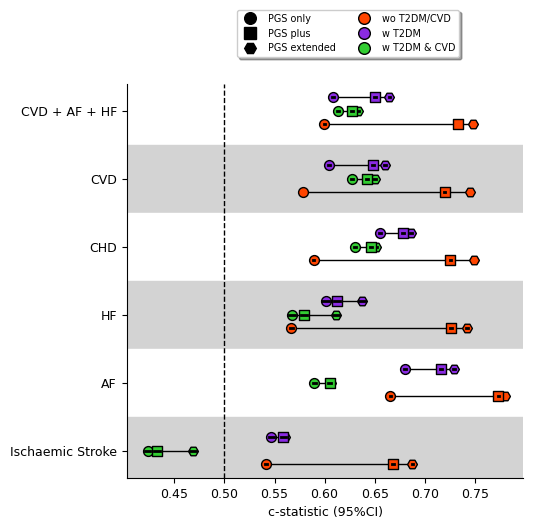

In [3]:
# figure
f, ax = plt.subplots(1, figsize=(13*CMTOINCH, 13*CMTOINCH))
forest1 = forest.ForestPlot(data=combined, x_col='test_cstatistic', lb_col='test_cstatistic_lb',
                           ub_col='test_cstatistic_ub', g_col='evaluated_outcome',
                           ax=ax, ) 
_, ax = forest1.plot(s_col='shape', c_col='col', s_size_col= 50, ci_colour='black',  
                     connect_shape=True, ylim=(-1,57),
                     kwargs_scatter_dict={'edgecolors':'black'},
                     kwargs_connect_segments_dict={'zorder':1},
                     verbose=True,
                    )

# Add plot look
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('c-statistic (95%CI)', fontsize=9)
ax.tick_params('both', labelsize=9)
ax.axvline(0.5, linewidth=1, linestyle='--', c='black')

# legend
SHAPE_val = list(SHAPE_DICT.values())
SHAPE_key = list(SHAPE_DICT.keys())
COL_val = list(COL_DICT.values())
COL_key = list(COL_DICT.keys())
leg_handles = []

for i in range(len(SHAPE_key)):
    leg_handles = leg_handles +  [
        Line2D([0], [0], marker=SHAPE_val[i], color='black',
               markersize=14, lw=0.0, label=SHAPE_key[i]
              )
    ]

for i in range(len(COL_key)):
    leg_handles = leg_handles +  [
        Line2D([0], [0], marker='o', color=COL_val[i],
               markersize=14, markeredgecolor='black', lw=0,
               label=COL_key[i]
              )
    ]

ax.legend(handles=leg_handles , ncol=2, bbox_to_anchor=(0.85, 1.20),
          fancybox=True, shadow=True, fontsize='x-small', markerscale=0.6
         )
# printing the span parameters. 
print('This is the span dictionary:')
print(forest1.span_dict)

## Classic forest plot

Next we will use the same function to depict a more classical forest plot with a single estimate and confidence interval on each line. Note that due to the study sample size the confidence are very small and plotting the confidence interval _on top_ of the shape will  look better (see the `zorder` parameter). 

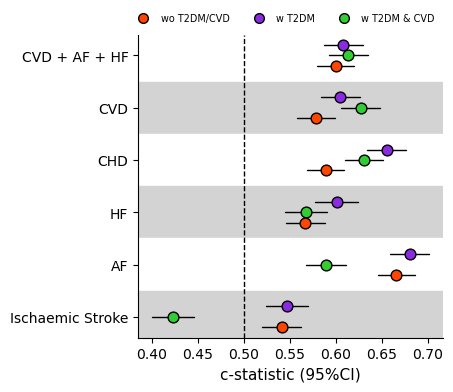

In [4]:
# increasing the ci to better showcase the function
single['test_cstatistic_lb'] = single['test_cstatistic_lb'] - 0.02
single['test_cstatistic_ub'] = single['test_cstatistic_ub'] + 0.02

# figure
f, ax = plt.subplots(1, figsize=(10*CMTOINCH, 10*CMTOINCH))
forest2 = forest.ForestPlot(data=single, x_col='test_cstatistic', lb_col='test_cstatistic_lb',
                             ub_col='test_cstatistic_ub', g_col='evaluated_outcome', ax=ax,)
_, ax = forest2.plot(s_col='shape', c_col='col', ci_colour='black', s_size_col= 60, ci_lwd=1,
                     ylim=(-1,57),
                     kwargs_scatter_dict={'edgecolors':'black'},
                     # plotting the confidence intervals behind the dots, and rounding the lines ends
                     kwargs_plot_ci_dict={'zorder':1, 'solid_capstyle':'round', 'linestyle':'-'} 
                    )

# change format
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('c-statistic (95%CI)', fontsize=11)
ax.tick_params('both', labelsize=10)
ax.axvline(0.5, linewidth=1, linestyle='--', c='black')

# legend
COL_val = list(COL_DICT.values())
COL_key = list(COL_DICT.keys())
leg_handles = []

for i in range(len(COL_key)):
    leg_handles = leg_handles +  [
        Line2D([0], [0], marker='o', color=COL_val[i],
               markersize=14, markeredgecolor='black', lw=0,
               label=COL_key[i]
              )
    ]

ax.legend(handles=leg_handles , ncol=3, bbox_to_anchor=(1.00, 1.10),
          frameon=False, fontsize='x-small', markerscale=0.5
         )

### Add side table
A side table with additional annotations can be added using a custom function and by splitting the figure into two panels with `gridspec`. In this example, we display the numerical values that underpin the bar chart. In other applications, the table could instead show alternative or supplementary information, depending on the context. 

To ensure the coloured span persists between panels this will be extracted from the forest object and passed to the `plot_table` function. 

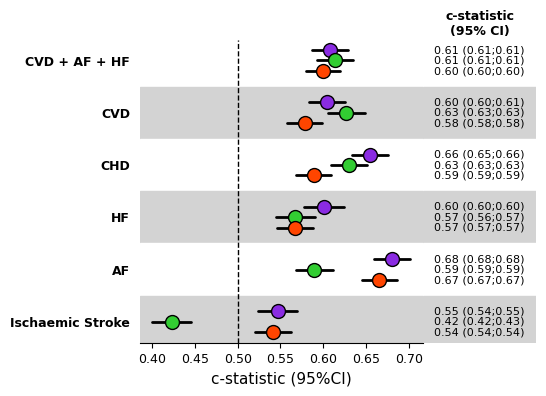

In [5]:
# create subplot and remove space
f, ax = plt.subplots(1, ncols=2, figsize=(13*CMTOINCH, 10*CMTOINCH),
                     gridspec_kw={'width_ratios': [10,4]},
                     sharey=False,
                     )
plt.subplots_adjust(wspace=0)

# add forest plot
forest3 = forest.ForestPlot(data=single, x_col='test_cstatistic',
                            lb_col='test_cstatistic_lb',
                            ub_col='test_cstatistic_ub',
                            g_col='evaluated_outcome', 
                            ax=ax[0],
                           )
_, _ = forest3.plot(s_col='shape', c_col='col', ci_colour='black',
                     s_size_col= 100, ci_lwd=2, ylim=(-1, 57),
                     kwargs_scatter_dict={'edgecolors':'black'},
                     kwargs_plot_ci_dict={'zorder':1, 'solid_capstyle':'round', 'linestyle':'-'}
                          )
ax[0].spines[['right', 'left', 'top']].set_visible(False)
ax[0].set_xlabel('c-statistic (95%CI)', fontsize=11)
ax[0].tick_params('both', labelsize=9, left=False)
ax[0].yaxis.set_ticklabels(ax[0].yaxis.get_ticklabels(),
                           weight='bold', size=9,
                          )
ax[0].axvline(0.5, linewidth=1, linestyle='--', c='black')

# add side-table
ax[1].set_ylim(ax[0].get_ylim())
span = forest3.span_dict
_ = forest.plot_table(single, annoteheader='c-statistic\n(95% CI)',
                  string_col=STRING_COL, ax=ax[1],
                  halignment_text='center',
                  halignment_header='center',
                  xloc_header=0.5,
                  size_text=8, size_header=9,
                  negative_padding=3,
                  span=span,
                  )


# Tree plots

Instead of plotting a forest of estimates, we can use tree plots to illustrate individual estimates and the parameter space which is supported by the observed data. Essentially this depicts the confidence interval emperical coverage across a range of values between 0 and 1. 


Text(0.32, 0.4, 'Excludes an\nHR of 1.25')

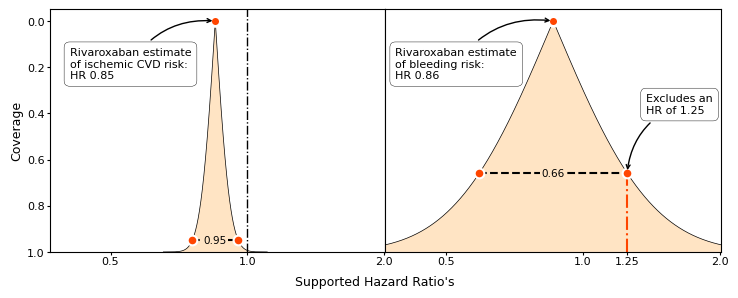

In [6]:
COL1='orangered'
COL2='white'
COL3='bisque'
TICK_LABEL_SIZE = 8
TITLE_SIZE = 5
ANNOT_LINE_WIDTH=1
ARROW_SCALE=7
MARKER_EDGE_SIZE=4
TICK_LENGTH = 2.5
AFONTSIZE=8
NEW_XAXIS=[ 0.50, 1.0, 1.50, 2.0, ]
STRING='string'
XLAB='HR (95%CI)'

ESTIMATES = list(np.log([0.85, 0.86]))
SE = list(np.divide([(np.log(0.96) - np.log(0.76)), (np.log(1.87) - np.log(0.40))], 3.92))
ALPHA=list(np.linspace(1, 0.00001, 10000))
NEW_XAXIS=[0.35, 0.50, 1.00, 2.00]
NEW_XAXIS=[NEW_XAXIS, NEW_XAXIS+[1.25]]
XMIN=np.log(0.86)-0.85
XMAX=np.log(0.86)+0.85
# the 0.65795 indicates the point the ub is less than 1.25
Y125=0.342041
UB125=0.6579592169216922
ANNOT_CI=[[0.95], [UB125]]

# plotting
f, ax = plt.subplots(1, ncols=2, figsize=(22*CMTOINCH, 8*CMTOINCH),
                     gridspec_kw={'width_ratios': [1,1],
                                  'wspace':0},
                     sharey=False,
                     )
for i, _ in enumerate(ax):
    space=forest.EmpericalSupport(estimate=ESTIMATES[i], standard_error=SE[i],
                                  alpha=ALPHA)
    _, _ = space.plot_tree(
        annotate_estimate=True, annotate_ci=ANNOT_CI[i],
        area_c='bisque',
        # support='compatibility',
        ax=ax[i],
        # line arguments
        linewidth=0.5,
        # dot arguments
        estimate_c=COL1, estimate_size=50, kwargs_dot={'edgecolor':COL2, 'linewidth':2},
        # area arguments
        area_a=1.00,
        # argument for the horizontal text
        kwargs_text={'fontsize':7.5, 'backgroundcolor':COL3,
                     'bbox':{'facecolor':COL3, 'alpha':1.00,
                             'edgecolor':'none', 'pad':1}},
        # arguments for the horizontal line
        kwargs_segment={'linestyle':'--', 'linewidth':1.5,
                        'markersize':7, 'markeredgewidth':1.5,
                        'markeredgecolor':COL2}
    )
    # axes
    plm_utils.utils.change_ticks(ax[i], ticks=NEW_XAXIS[i], log=True)
    ax[i].set_xlim(XMIN, XMAX)
    ax[i].tick_params(axis='x', labelsize=TICK_LABEL_SIZE, length=TICK_LENGTH,
                      pad=0.5)
    ax[i].set_xlabel(None)
    ax[i].set_ylim(1.0, ax[i].get_ylim()[1])

# ###### add a vertical line
ax[0].axvline(0.0, linewidth=1.0, linestyle='-.', c='black')
ax[1].axvline(np.log(1.25),  linewidth=1.5, ymax=Y125,
              linestyle='-.', c=COL1, zorder=1)
# ##### Working on a specific axis
ax[0].set_ylabel(ax[0].get_ylabel(), fontsize=9, labelpad=3.0,)
ax[0].tick_params(axis='y', labelsize=TICK_LABEL_SIZE, length=TICK_LENGTH,
                  pad=1.0,)
ax[1].set_yticks([])
ax[1].set_yticklabels([])
ax[1].set_ylabel(None)
# ##### Common label
f.text(0.5, 0.005, "Supported Hazard Ratio's", ha='center',
         fontsize=9)
# #### Annotations
ax[0].annotate( 'Rivaroxaban estimate\nof ischemic CVD risk:\nHR {}'.\
               format(np.exp(ESTIMATES[0])),
               xy=(ESTIMATES[0], 0), xytext=(-0.9, 0.25),
               fontsize=AFONTSIZE,
               arrowprops=dict(
                   arrowstyle='->', connectionstyle='arc3,rad=-0.3',
                   linewidth=ANNOT_LINE_WIDTH, mutation_scale=ARROW_SCALE,
               ),
               bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=1.0,
                         linewidth=0.3, edgecolor='black',
                         )
               )
ax[1].annotate( 'Rivaroxaban estimate\nof bleeding risk:\nHR {}'.\
               format(np.exp(ESTIMATES[1])),
               xy=(ESTIMATES[1], 0), xytext=(-0.95, 0.25),
               fontsize=AFONTSIZE,
               arrowprops=dict(
                   arrowstyle='->', connectionstyle='arc3,rad=-0.3',
                   linewidth=ANNOT_LINE_WIDTH, mutation_scale=ARROW_SCALE,
               ),
               bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=1.0,
                         linewidth=0.3, edgecolor='black',
                         )
               )

ax[1].annotate( 'Excludes an\nHR of 1.25'.\
               format(np.exp(ESTIMATES[1])),
               xy=(np.log(1.25), 1-Y125), xytext=(0.32, 0.40),
               fontsize=AFONTSIZE,
               arrowprops=dict(
                   arrowstyle='->', connectionstyle='arc3,rad=0.3',
                   linewidth=ANNOT_LINE_WIDTH, mutation_scale=ARROW_SCALE,
               ),
               bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=1.0,
                         linewidth=0.3, edgecolor='black',
                         )
               )



In [7]:
help(forest)

Help on module plot_misc.forest in plot_misc:

NAME
    plot_misc.forest

DESCRIPTION
    This module provides functions and classes to construct forest plots,
    annotated side tables, and compatibility (empirical support) plots.
    
    Results are returned as structured result classes, and plotting functions
    allow fine-grained control via `kwargs_*_dict` arguments passed directly to
    matplotlib primitives.
    
    Classes
    -------
    ForestPlot
        A class to draw a forest plot, with point estimates and confidence
        intervals.
    
    EmpericalSupport
        A class to compute and visualise empirical support (or compatibility)
        intervals for a given estimate and standard error across a range of
        alpha (i.e. type 1 error) values.
    
    EmpericalSupportPlotResults
        Stores the full results table and estimate from an empirical support plot.
    
    Functions
    ---------
    plot_table
        Annotate a matplotlib axes with a table al